In [1]:
import os
os.chdir("../")

In [2]:
!pwd

/home/vanishhhed/Desktop/codics/PythonCodics/ML/XAI/Grad-Cam


In [3]:
import numpy as np
import torch
import torch.nn as nn
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
from PIL import Image
import torch.nn.functional as F

from src.dataset.dataset import _load_config
from src.models.resemotenet import ResEmoteNet

config = _load_config()
MODEL_PATH = config["models"]["resemotenet"]

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

emotion_labels = {
    0: "Anger", 1: "Disgust", 2: "Fear", 3: "Happy",
    4: "Sad", 5: "Surprise", 6: "Neutral",
}

Using device: cpu


In [7]:
model = ResEmoteNet(num_classes=7, input_size=100)
model.load_state_dict(torch.load(MODEL_PATH, map_location=device))
model = model.to(device)
model.eval()

target_layer = model.res_blocks[-1]

your_image_path = "src/image copy 4.png"
original_image = Image.open(your_image_path).convert("RGB")

# ResEmoteNet expects 100x100 input
display_transform = transforms.Compose([
    transforms.Resize((100, 100)),
])
img_display = np.array(display_transform(original_image))

val_transform = transforms.Compose([
    transforms.Resize((100, 100)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225],
    ),
])

input_tensor = val_transform(original_image).unsqueeze(0).to(device)

In [ ]:
class VGG(nn.Module):
    def __init__(self, vgg_name):
        super(VGG, self).__init__()
        self.features = self._make_layers(cfg[vgg_name])
        self.classifier = nn.Linear(512, 7)

    def forward(self, x):
        out = self.features(x)
        out = out.view(out.size(0), -1)
        out = F.dropout(out, p=0.5, training=self.training)
        out = self.classifier(out)
        return out

    def _make_layers(self, cfg):
        layers = []
        in_channels = 3
        for x in cfg:
            if x == 'M':
                layers += [nn.MaxPool2d(kernel_size=2, stride=2)]
            else:
                layers += [nn.Conv2d(in_channels, x, kernel_size=3, padding=1),
                           nn.BatchNorm2d(x),
                           nn.ReLU(inplace=True)]
                in_channels = x
        layers += [nn.AvgPool2d(kernel_size=1, stride=1)]
        return nn.Sequential(*layers)


cfg = {
    'VGG19': [64, 64, 'M', 128, 128, 'M', 256, 256, 256, 256, 'M',
              512, 512, 512, 512, 'M', 512, 512, 512, 512, 'M'],
}



model = VGG('VGG19')
checkpoint = torch.load('models/PrivateTest_model.t7', map_location=torch.device('cpu'), weights_only=False)
model.load_state_dict(checkpoint['net'])
model = model.to(device)
model.eval()

target_layer = model.features[-3]
preprocess = transforms.Compose([
    transforms.Grayscale(num_output_channels=3),
    transforms.Resize((48, 48)),
    transforms.ToTensor(),
])

resize = transforms.Resize((48, 48))

image_path = ""
# image_path = "src/sadness1.png"
# image_path = "src/photo_2026-03-19_15-45-15.jpg"
img_display = Image.open(image_path).convert("RGB")
input_tensor = preprocess(img_display).unsqueeze(0).to(device)

In [74]:
print(target_layer)

ReLU(inplace=True)


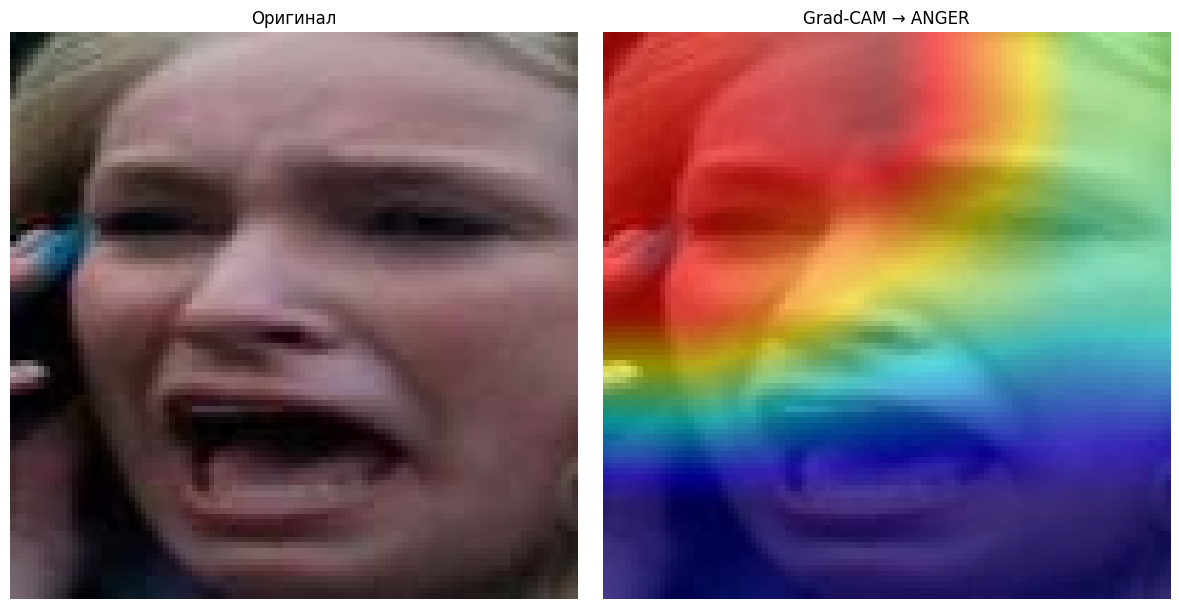

In [ ]:
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget
from pytorch_grad_cam.utils.image import show_cam_on_image

with GradCAM(model=model, target_layers=[target_layer]) as cam:
    
    with torch.no_grad():
        logits = model(input_tensor)
        predicted_class = torch.argmax(logits, dim=1).item()
        # probabilities = torch.softmax(logits, dim=1)[0]
        
    targets = [ClassifierOutputTarget(predicted_class)]
    grayscale_cam = cam(input_tensor=input_tensor, targets=targets)[0, :]
    
rgb_img = np.array(img_display) / 255.0

cam_tensor = torch.from_numpy(grayscale_cam).unsqueeze(0).unsqueeze(0)  # [1, 1, 48, 48]
cam_resized = F.interpolate(
    cam_tensor,
    size=(rgb_img.shape[0], rgb_img.shape[1]),   # 100×100
    mode='bilinear',
    align_corners=False
).squeeze().numpy()

visualization = show_cam_on_image(rgb_img, cam_resized, use_rgb=True)

plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.imshow(img_display)
plt.title("Original")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(visualization)
plt.title(f"Grad-CAM -> {emotion_labels[predicted_class].upper()}")
plt.axis("off")

plt.tight_layout()
plt.show()

Предсказанная эмоция: SURPRISE


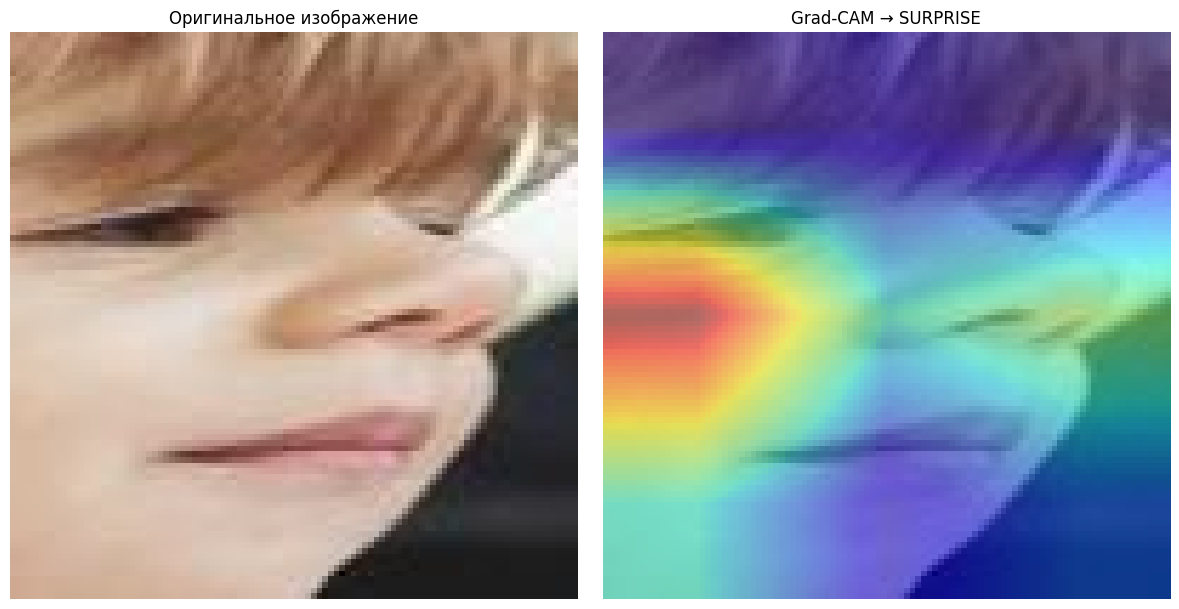

In [ ]:
from src.gradcam.grad_cam import GradCAM as MyGradCAM

my_gradcam = MyGradCAM(model, target_layer)
cam = my_gradcam(input_tensor)

my_gradcam.remove_hooks()

with torch.no_grad():
    output = model(input_tensor)
    pred_class = output.argmax(dim=1).item()
    
emotion_labels = ["angry", "disgust", "fear", "happy", "sad", "surprise", "neutral"]
print(f"Предсказанная эмоция: {emotion_labels[pred_class].upper()}")

cam_tensor = torch.from_numpy(cam).unsqueeze(0).unsqueeze(0)  # [1, 1, H', W']
cam_resized = F.interpolate(
    cam_tensor,
    size=(100, 100),
    mode="bilinear",
    align_corners=False
).squeeze().numpy()


fig, ax = plt.subplots(1, 2, figsize=(12, 6))

ax[0].imshow(img_display)
ax[0].set_title("Original")
ax[0].axis("off")

ax[1].imshow(img_display)
ax[1].imshow(cam_resized, cmap="jet", alpha=0.5)
ax[1].set_title(f"Grad-CAM -> {emotion_labels[pred_class].upper()}")
ax[1].axis("off")

plt.tight_layout()
plt.show()